In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/glory_dataset.zip /content/

In [ ]:
!unzip -q /content/glory_dataset.zip -d /content/glory_dataset

In [1]:
!pip install ultralytics clearml

In [2]:
%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
%env CLEARML_API_ACCESS_KEY=3QWKRZS29A5BDSZ32KHBKSXSXPCMS9
%env CLEARML_API_SECRET_KEY=daWtIaCfSgp8zvflzPKbqQITnihZncd6aIZMkJn3K5VrK0bVCsysV7qUsWO8HOetK00

env: CLEARML_WEB_HOST=https://app.clear.ml/
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml
env: CLEARML_API_ACCESS_KEY=3QWKRZS29A5BDSZ32KHBKSXSXPCMS9
env: CLEARML_API_SECRET_KEY=daWtIaCfSgp8zvflzPKbqQITnihZncd6aIZMkJn3K5VrK0bVCsysV7qUsWO8HOetK00


In [3]:
!nvidia-smi
import torch
print(f"CUDA доступна: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Sun Jun 28 13:16:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

ClearML Task: created new task id=374003de12f942259027216c5e580ce2
2026-06-28 13:16:55,257 - clearml.Task - INFO - Storing jupyter notebook directly as code
ClearML results page: https://app.clear.ml/projects/02524a81ed9d4a8e832be4100f197833/experiments/374003de12f942259027216c5e580ce2/output/log
2026-06-28 13:17:05,233 - clearml.model - INFO - A model with uri "file:///content/yolo11s.pt" already exists. Selecting it
2026-06-28 13:17:05,240 - clearml.model - INFO - Selected model id: efc16ba7d6e5469fb38f75723d89a6e2
New https://pypi.org/project/ultralytics/8.4.81 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.25, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, d

                                           0% | 0.00/18.34 MB [00:00<?, ?MB/s]: 

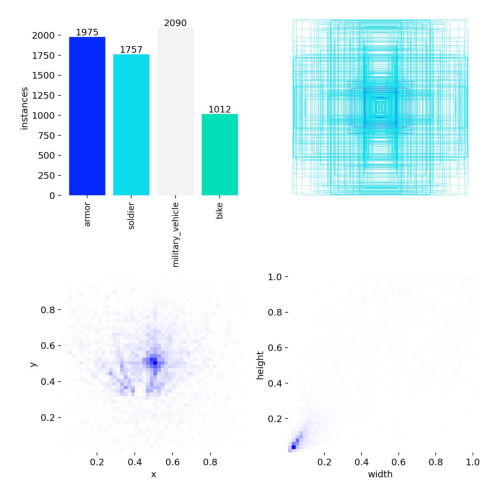

████████████████▉                55% | 10.00/18.34 MB [00:00<00:00, 22.56MB/s]: 

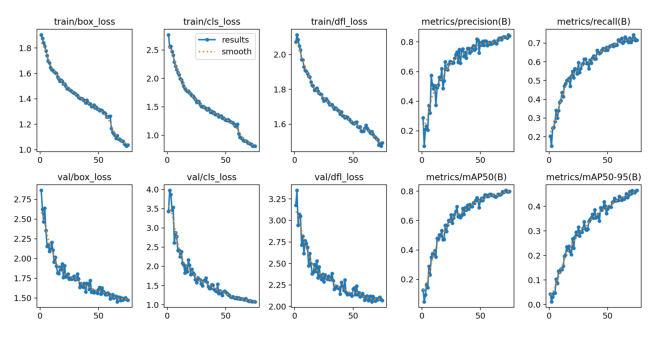

███████████████████████████████ 100% | 18.34/18.34 MB [00:01<00:00, 15.39MB/s]: 

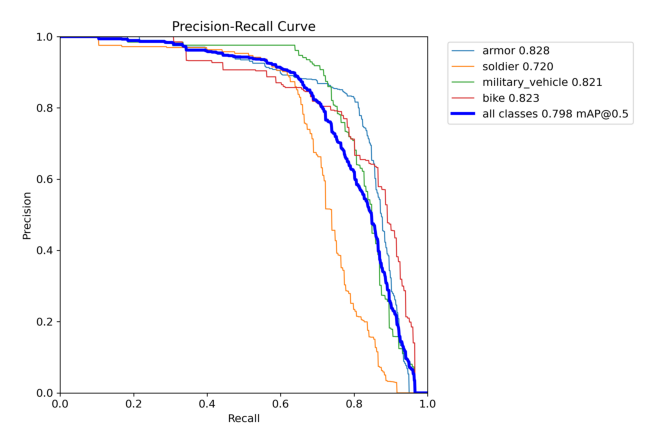

███████████████████████████████ 100% | 18.34/18.34 MB [00:01<00:00, 12.10MB/s]: 

2026-06-28 16:49:39,984 - clearml.Task - INFO - Completed model upload to https://files.clear.ml/yolo11_glory/my_yolo11s_train_colab_gpu.374003de12f942259027216c5e580ce2/models/best.pt


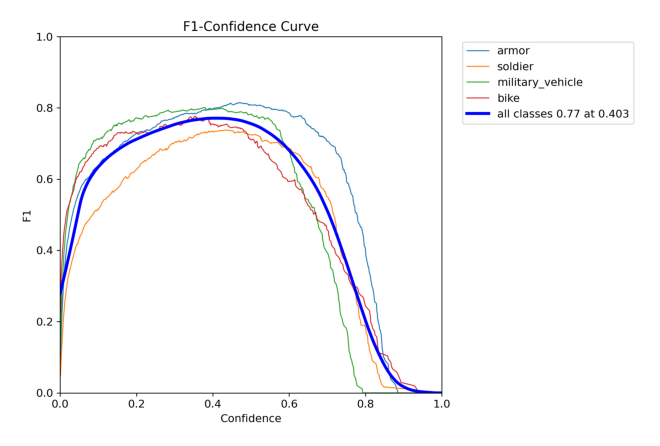

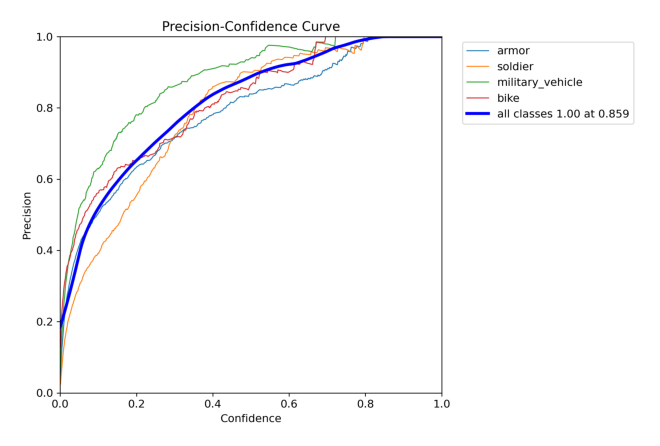

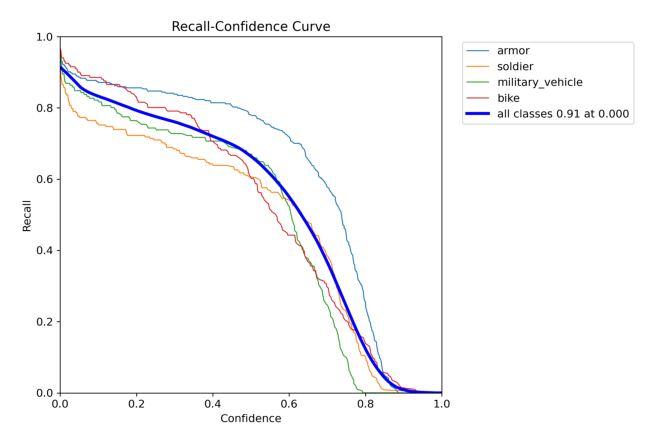

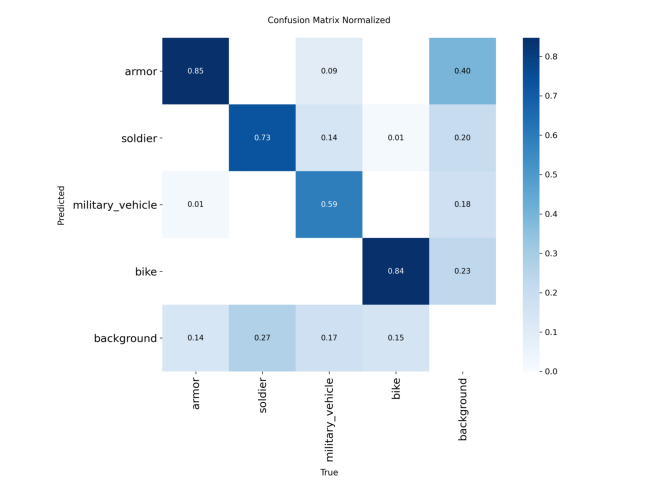

In [4]:
from clearml import Task
from ultralytics import YOLO

task = Task.init(
    project_name="yolo11_glory",
    task_name="my_yolo11s_train_colab_gpu"
)

model_variant = "yolo11s.pt"
task.set_parameter("model_variant", model_variant)
model = YOLO(model_variant)

args = dict(
    data="/content/glory_dataset/glory_dataset/glory_dataset.yaml",
    epochs=75,
    imgsz=896,
    batch=16,
    device="0",
    workers=4,
    amp=True,
    lr0=0.005,
    patience=15,
    seed=42,
    cls_pw=0.25,
    mosaic=1.0,
    close_mosaic=15,
    degrees=45.0,
    flipud=0.3,
    fliplr=0.5,
    scale=0.75,
    translate=0.1,
    perspective=0.0005,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.5,
    mixup=0.0,
    copy_paste=0.0
)

task.connect(args)
results = model.train(**args)

In [5]:
!cp -r /content/runs /content/drive/MyDrive/glory_results